# Inference Example: vit_adapter_dinov2_vitb14-multitask_mask2former_head
This notebook demonstrates loading a trained model from a checkpoint and running inference on a sample RGB image.

In [1]:
# Import required libraries
import torch
from PIL import Image
import numpy as np
import torchvision.transforms as T
import sys
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('.')  # Ensure local imports work

In [26]:
# Load model config and instantiate model
from config.model import ViTAdapterDinov2ViTB14MultitaskMask2FormerHeadConfig
# from models.full_model import EncoderDecoderModel  # Adjust if your model class is named differently
from models import create_model
from train import load_checkpoint_config

path = "./omniroad_checkpoints/manual_unified_label/best_model.pth"
checkpoint = torch.load(path, map_location='cpu')
# print(checkpoint)
model = create_model(checkpoint['config'])
config = checkpoint['config']


Using cache found in /home/yunjinli/.cache/torch/hub/facebookresearch_dinov2_main


In [27]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))
model.load_state_dict(checkpoint['model_state_dict'], strict=False)
model.eval()
model.to('cuda')

EncoderDecoderModel(
  (encoder): ViTAdapter(
    (encoder): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x NestedTensorBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features=3072, out_features=

In [28]:
# Load and preprocess image
# img_path = './omniroad_checkpoints/ac73d367-0cb39ad0.jpg'  # Update this path
# img_path = './omniroad_checkpoints/1.GH011220 0174.jpg'  # Update this path
# img_path = './omniroad_checkpoints/1.GH011220 1851.jpg'  # Update this path
# img_path = './omniroad_checkpoints/GH011222 00436.jpg'  # Update this path
# img_path = './omniroad_checkpoints/aca4b150-00000000.jpg'  # Update this path
# img_path = './omniroad_checkpoints/ae5f775e-0abb299c.jpg'  # Update this path
# img_path = './omniroad_checkpoints/new-york-city-street-scene-photo-by-paul-katcher.jpg'  # Update this path
# img_path = './omniroad_checkpoints/original.jpg'  # Update this path
# img_path = './omniroad_checkpoints/bad_road.jpg'  # Update this path
img_path = './omniroad_checkpoints/sixdriving-condition.jpg'  # Update this path



img = Image.open(img_path).convert('RGB')
print(img.size)
# Resize and normalize as required by your model
transform = T.Compose([
    T.Resize(config.data.input_size),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0).to('cuda')  # Add batch dimension

(453, 302)


In [29]:
# Run inference
with torch.no_grad():
    predictions, outputs = model(input_tensor)


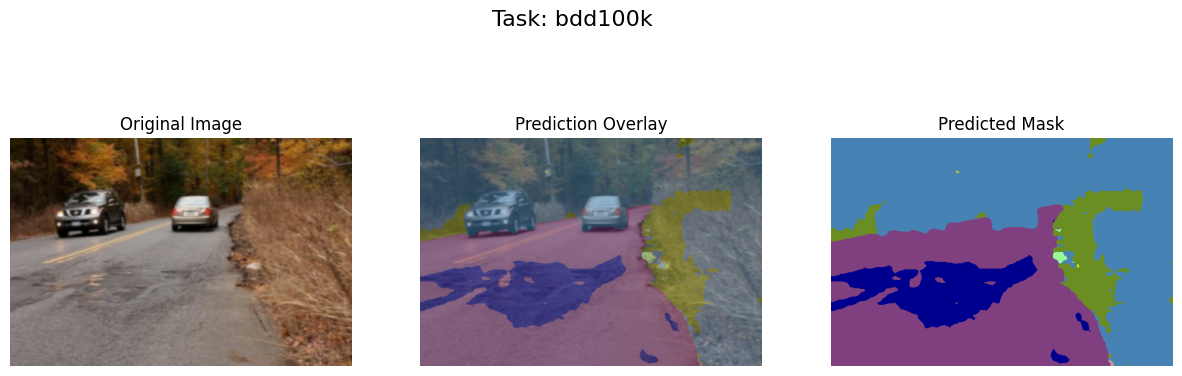

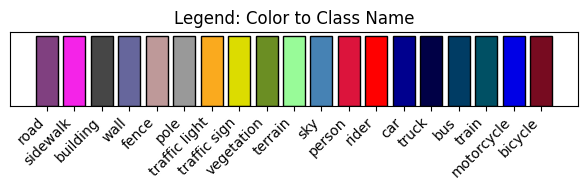

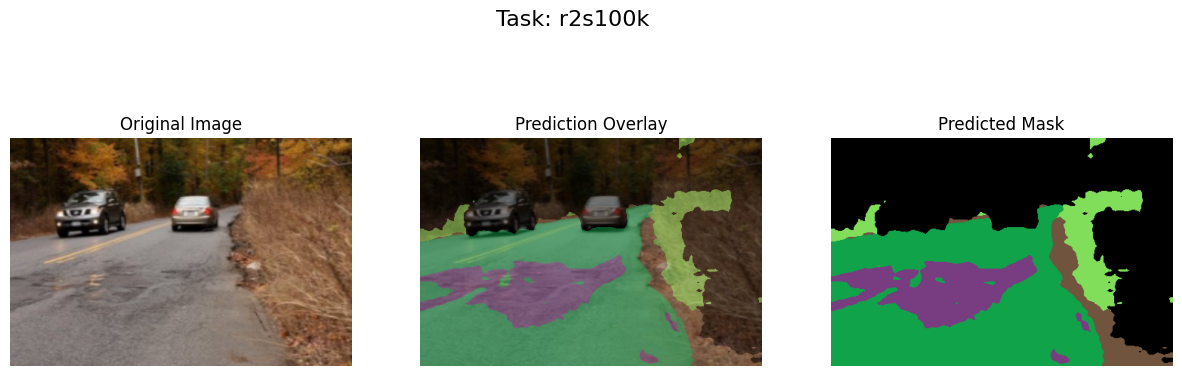

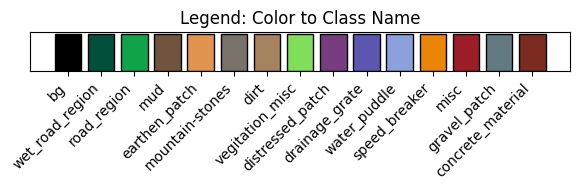

In [30]:
import torch.nn.functional as F
%matplotlib inline
for task_name in config.tasks:
# task_name = 'bdd100k'
# task_name = 'r2s100k'
    mask_cls_results = outputs[task_name]["pred_logits"]
    mask_pred_results = outputs[task_name]["pred_masks"]
    # print(mask_pred_results.shape)
    mask_pred_results = F.interpolate(
                                    mask_pred_results,
                                    # size=config.data.input_size,
                                    size=img.size[::-1],  # (H, W)
                                    mode="bilinear",
                                    align_corners=False,
                                )
    # Visualize all masks from mask_pred_results
    # num_masks = mask_pred_results.shape[1]
    # ncols = 10
    # nrows = (num_masks + ncols - 1) // ncols
    # fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    # axes = axes.flatten()
    # for i in range(num_masks):
    #     ax = axes[i]
    #     ax.imshow(mask_pred_results[0][i].cpu().numpy(), cmap='viridis')
    #     ax.set_title(f"Mask {i}")
    #     ax.axis('off')
    # # Hide unused subplots
    # for i in range(num_masks, nrows * ncols):
    #     axes[i].axis('off')
    # plt.tight_layout()
    # plt.show()
    
    outputs_map = []
    for mask_cls_result, mask_pred_result in zip(mask_cls_results, mask_pred_results):
        semmap = model.decoder.semantic_inference(mask_cls_result, mask_pred_result)
        outputs_map.append(semmap)
    outputs_map = torch.stack(outputs_map)[0]
    # print(outputs_map.shape)  # (1, num_classes, H, W)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Task: {task_name}", fontsize=16)
    mean = torch.tensor(config.data.mean).view(3, 1, 1).to(input_tensor.device)
    std = torch.tensor(config.data.std).view(3, 1, 1).to(input_tensor.device)
    image_denorm = input_tensor[0] * std + mean
    image_np = image_denorm.cpu().numpy().transpose(1, 2, 0)
    image_np = np.clip(image_np, 0, 1)
    image_pil = Image.fromarray((image_np * 255).astype(np.uint8))
    image_resized = image_pil.resize(img.size, Image.BILINEAR)
    image_np = np.array(image_resized).astype(np.float32) / 255.0
    if outputs_map.dim() == 3:  # [C, H, W]
        predicted_mask = torch.argmax(outputs_map, dim=0).cpu().numpy()
    else:  # [H, W]
        predicted_mask = outputs_map.cpu().numpy()
    ax1.imshow(image_np)
    ax1.set_title("Original Image")
    ax1.axis('off')

    label_colors_list, class_names = config.data.parse_color_and_names(task=task_name)
    class_colors = torch.tensor(label_colors_list, dtype=torch.float32) / 255.0
    pred_colored = np.zeros((predicted_mask.shape[0], predicted_mask.shape[1], 3))
    for class_idx in range(len(class_colors)):
        class_mask = predicted_mask == class_idx
        pred_colored[class_mask] = class_colors[class_idx].cpu().numpy()
        
    # Show prediction as overlay
    ax2.imshow(image_np)
    ax2.imshow(pred_colored, alpha=0.5)
    ax2.set_title("Prediction Overlay")
    ax2.axis('off')

    ax3.imshow(pred_colored)
    ax3.set_title("Predicted Mask")
    ax3.axis('off')

    # Visualize legend: color to class name for predicted mask


    # Example: class names and colors (update these for your dataset)
    class_colors = label_colors_list

    fig, ax = plt.subplots(figsize=(6, 2))
    for idx, (name, color) in enumerate(zip(class_names, class_colors)):
        ax.bar(idx, 1, color=np.array(color)/255, edgecolor='k')
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks([])
    ax.set_title('Legend: Color to Class Name')
    plt.tight_layout()
    plt.show()

['road', 'sidewalk', 'building', 'wall', 'fence', 'pole', 'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky', 'person', 'rider', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle']


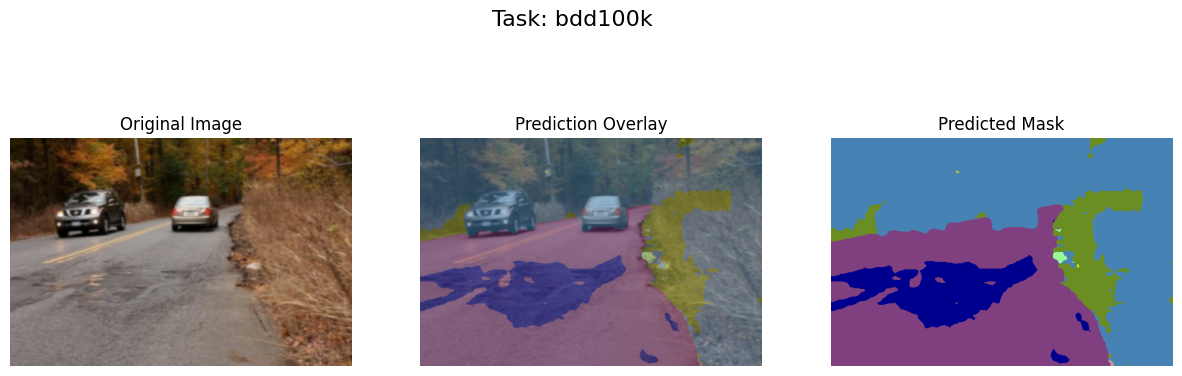

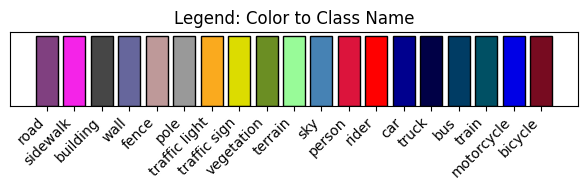

['bg', 'wet_road_region', 'road_region', 'mud', 'earthen_patch', 'mountain-stones', 'dirt', 'vegitation_misc', 'distressed_patch', 'drainage_grate', 'water_puddle', 'speed_breaker', 'misc', 'gravel_patch', 'concrete_material']


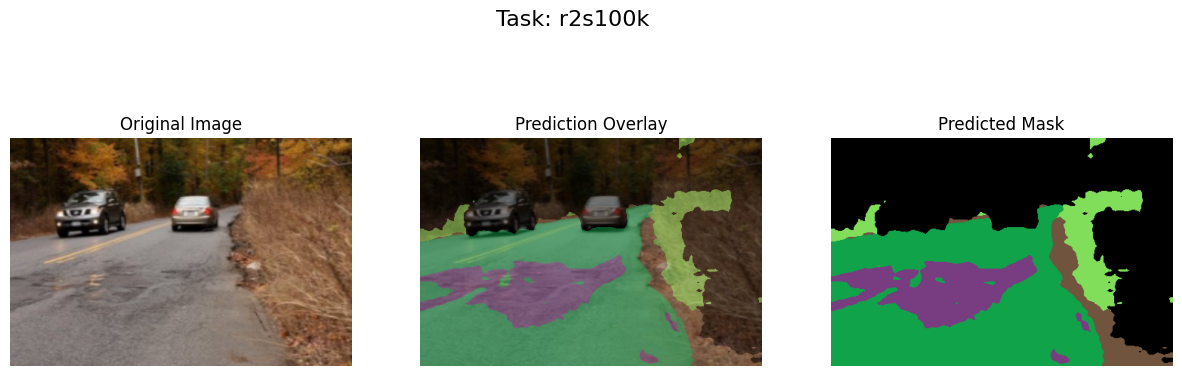

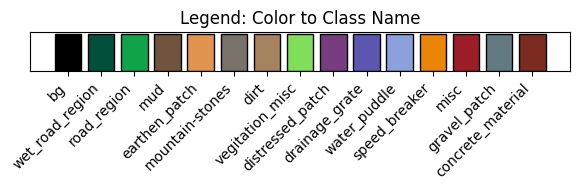

In [31]:
import torch.nn.functional as F

for task_name in config.tasks:
# task_name = 'bdd100k'
# task_name = 'r2s100k'
    mask_cls_results = outputs[task_name]["pred_logits"]
    mask_pred_results = outputs[task_name]["pred_masks"]

    mask_pred_results = F.interpolate(
                                    mask_pred_results,
                                    # size=config.data.input_size,
                                    size=img.size[::-1],  # (H, W)
                                    mode="bilinear",
                                    align_corners=False,
                                )
    outputs_map = []
    for mask_cls_result, mask_pred_result in zip(mask_cls_results, mask_pred_results):
        semmap = model.decoder.semantic_inference(mask_cls_result, mask_pred_result)
        outputs_map.append(semmap)
    outputs_map = torch.stack(outputs_map)[0]
    # print(outputs_map.shape)  # (1, num_classes, H, W)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Task: {task_name}", fontsize=16)
    mean = torch.tensor(config.data.mean).view(3, 1, 1).to(input_tensor.device)
    std = torch.tensor(config.data.std).view(3, 1, 1).to(input_tensor.device)
    image_denorm = input_tensor[0] * std + mean
    image_np = image_denorm.cpu().numpy().transpose(1, 2, 0)
    image_np = np.clip(image_np, 0, 1)
    image_pil = Image.fromarray((image_np * 255).astype(np.uint8))
    image_resized = image_pil.resize(img.size, Image.BILINEAR)
    image_np = np.array(image_resized).astype(np.float32) / 255.0
    if outputs_map.dim() == 3:  # [C, H, W]
        predicted_mask = torch.argmax(outputs_map, dim=0).cpu().numpy()
    else:  # [H, W]
        predicted_mask = outputs_map.cpu().numpy()
    ax1.imshow(image_np)
    ax1.set_title("Original Image")
    ax1.axis('off')

    label_colors_list, class_names = config.data.parse_color_and_names(task=task_name)
    print(class_names)
    class_colors = torch.tensor(label_colors_list, dtype=torch.float32) / 255.0
    pred_colored = np.zeros((predicted_mask.shape[0], predicted_mask.shape[1], 3))
    for class_idx in range(len(class_colors)):
        class_mask = predicted_mask == class_idx
        pred_colored[class_mask] = class_colors[class_idx].cpu().numpy()
        
    # Show prediction as overlay
    ax2.imshow(image_np)
    ax2.imshow(pred_colored, alpha=0.5)
    ax2.set_title("Prediction Overlay")
    ax2.axis('off')

    ax3.imshow(pred_colored)
    ax3.set_title("Predicted Mask")
    ax3.axis('off')

    # Visualize legend: color to class name for predicted mask


    # Example: class names and colors (update these for your dataset)
    class_colors = label_colors_list

    fig, ax = plt.subplots(figsize=(6, 2))
    for idx, (name, color) in enumerate(zip(class_names, class_colors)):
        ax.bar(idx, 1, color=np.array(color)/255, edgecolor='k')
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks([])
    ax.set_title('Legend: Color to Class Name')
    plt.tight_layout()
    plt.show()

torch.Size([1, 100, 30])
torch.Size([30, 302, 453])


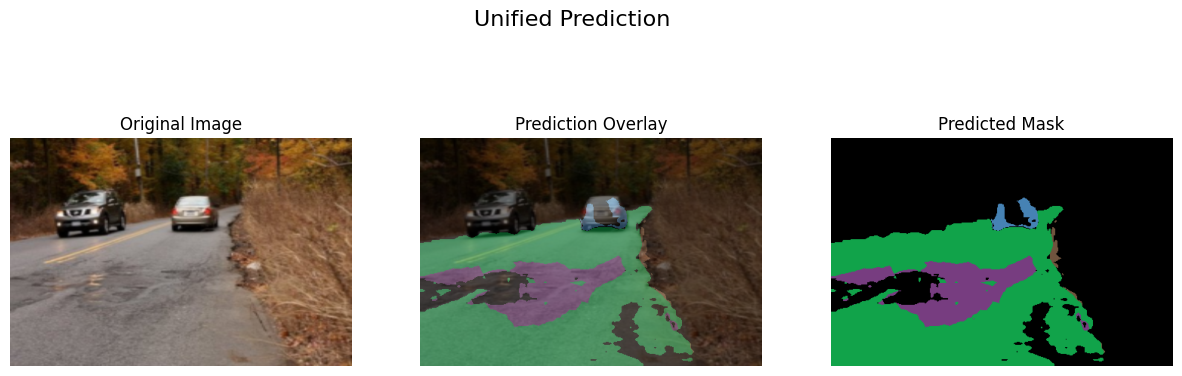

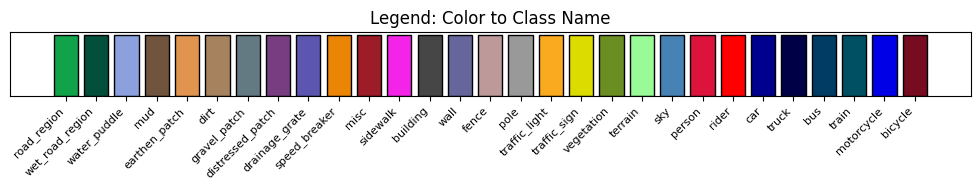

In [ ]:
import random

import torch.nn.functional as F
# import matplotlib
%matplotlib inline
# Fuse the logits and masks from both tasks and perform unified prediction

# Collect logits and masks from all tasks
fused_logits = predictions["pred_logits"]
fused_masks = predictions["pred_masks"]
print(fused_logits.shape)
fused_masks = F.interpolate(
        fused_masks,
        size=img.size[::-1],  # (H, W)
        mode="bilinear",
        align_corners=False,
    )

## Ignore no_object
# outputs_map = model.decoder.semantic_inference(fused_logits[0], fused_masks[0])
##

## Consider no_object
mask_cls = F.softmax(fused_logits[0], dim=-1)
mask_pred = fused_masks[0].sigmoid()
outputs_map = torch.einsum("qc,qhw->chw", mask_cls, mask_pred)
##

print(outputs_map.shape)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Unified Prediction", fontsize=16)
mean = torch.tensor(config.data.mean).view(3, 1, 1).to(input_tensor.device)
std = torch.tensor(config.data.std).view(3, 1, 1).to(input_tensor.device)
image_denorm = input_tensor[0] * std + mean
image_np = image_denorm.cpu().numpy().transpose(1, 2, 0)
image_np = np.clip(image_np, 0, 1)
image_pil = Image.fromarray((image_np * 255).astype(np.uint8))
image_resized = image_pil.resize(img.size, Image.BILINEAR)
image_np = np.array(image_resized).astype(np.float32) / 255.0
if outputs_map.dim() == 3:  # [C, H, W]
    predicted_mask = torch.argmax(outputs_map, dim=0).cpu().numpy()
else:  # [H, W]
    predicted_mask = outputs_map.cpu().numpy()
ax1.imshow(image_np)
ax1.set_title("Original Image")
ax1.axis('off')

# Use the first task's color map and class names for visualization
# Detect duplicate colors in unified_label_colors and change duplicates to new unique colors

def generate_unique_color(existing_colors):
    while True:
        color = tuple(random.randint(0, 255) for _ in range(3))
        if color not in existing_colors:
            return color

unified_label_colors = config.data.get_manual_superset_color_and_names()['sup_colors']
unified_class_names = config.data.get_manual_superset_color_and_names()['sup_names']
# Find duplicates
color_to_indices = {}
for idx, color in enumerate(unified_label_colors):
    color_to_indices.setdefault(color, []).append(idx)

# Replace duplicates with new unique colors (keep the first occurrence)
new_unified_label_colors = list(unified_label_colors)
existing_colors = set(unified_label_colors)
for color, indices in color_to_indices.items():
    if len(indices) > 1:
        # Keep the first, change the rest
        for dup_idx in indices[1:]:
            new_color = generate_unique_color(existing_colors)
            new_unified_label_colors[dup_idx] = new_color
            existing_colors.add(new_color)

class_colors = torch.tensor(new_unified_label_colors, dtype=torch.float32) / 255.0

if outputs_map.dim() == 3:  # [C, H, W]
    predicted_mask = torch.argmax(outputs_map, dim=0).cpu().numpy()
else:  # [H, W]
    predicted_mask = outputs_map.cpu().numpy()

pred_colored = np.zeros((predicted_mask.shape[0], predicted_mask.shape[1], 3))
for class_idx in range(len(class_colors)):
    class_mask = predicted_mask == class_idx
    pred_colored[class_mask] = class_colors[class_idx].cpu().numpy()

ax2.imshow(image_np)
ax2.imshow(pred_colored, alpha=0.5)
ax2.set_title("Prediction Overlay")
ax2.axis('off')

ax3.imshow(pred_colored)
ax3.set_title("Predicted Mask")
ax3.axis('off')

# Legend
fig, ax = plt.subplots(figsize=(10, 2))
for idx, (name, color) in enumerate(zip(unified_class_names, new_unified_label_colors)):
    ax.bar(idx, 1, color=np.array(color)/255, edgecolor='k')
ax.set_xticks(range(len(unified_class_names)))
ax.set_xticklabels(unified_class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks([])
ax.set_title('Legend: Color to Class Name')
plt.tight_layout()
plt.show()

torch.Size([1, 99, 30])
[10 18 24 24 13  2 24 24  5  5  6  5 24  1 24 24  2 13 24  1  7 24 24 13
 19 24  2 24  7 19  2  2 15 24 24 13  1 19 24 24 14 12 13 19 19  6  1 13
  7 24 24 24 24 24  3  6 24 12 13  6 24  7  7 19  7 24 20  7 24 14 18  1
 24 13 24 13 14  5 12  7 21 14  0 24 12 24  2  1  7 17  5  6  1  6  5  6
 19 20 24 24]


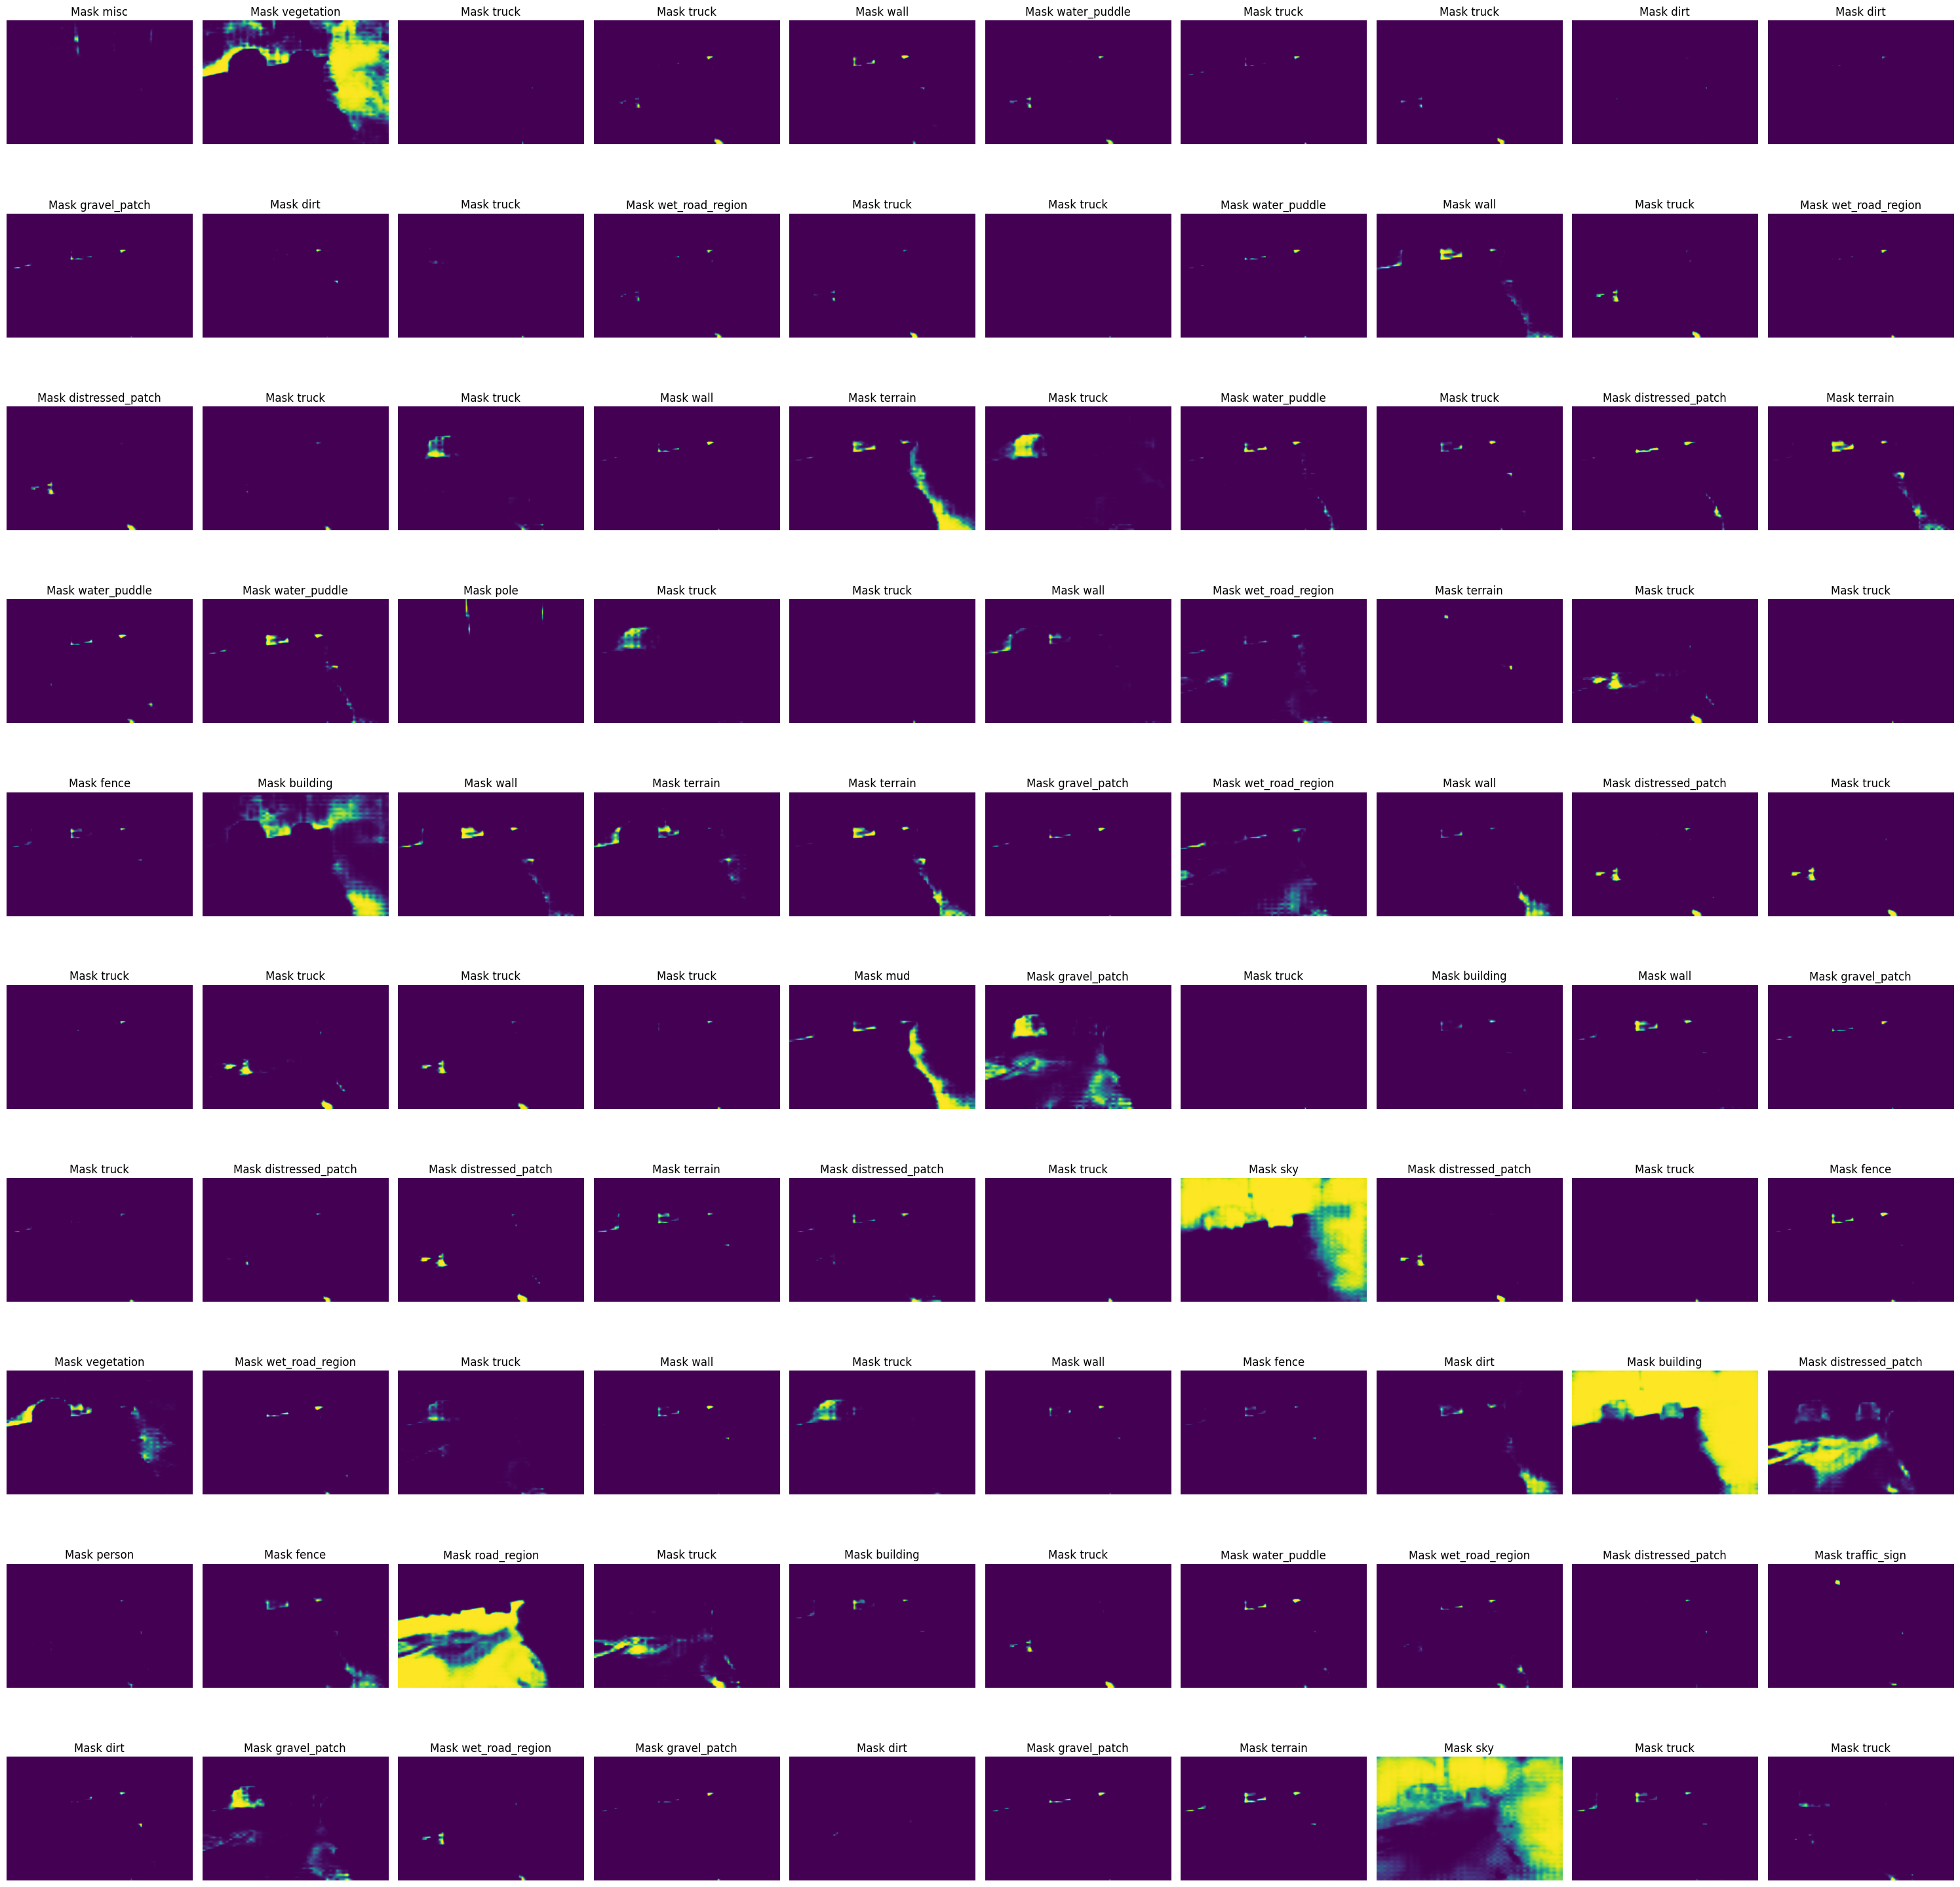

In [ ]:
# print(fused_logits[:, :-1].shape)
max_ids = torch.argmax(fused_logits[:, :, :-1], dim=-1).int().cpu().numpy()[0]
# print(max_ids)
num_masks = fused_masks.shape[1]
ncols = 10
nrows = (num_masks + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten()
for i in range(num_masks):
    ax = axes[i]
    ax.imshow(mask_pred_results[0][i].sigmoid().cpu().numpy(), cmap='viridis')
    ax.set_title(f"Mask {unified_class_names[max_ids[i]]}")
    ax.axis('off')
# Hide unused subplots
for i in range(num_masks, nrows * ncols):
    axes[i].axis('off')
plt.tight_layout()
plt.show()